# Exploratory Data Analysis (EDA)

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Load the ML Dataset

In [74]:
# Load the Barcelona noise ML dataset
dataset = pd.read_csv("../../data/machine_learning/bcn_noise_ml_dataset.csv")

print(f"Dataset shape: {dataset.shape}")
dataset.head()
print(dataset.columns.tolist())

Dataset shape: (15115, 21)
['street_id', 'noise_day', 'noise_evening', 'noise_night', 'road_length', 'road_category', 'fid', 'osm_commercial_pct_50m', 'osm_green_pct_50m', 'osm_industrial_pct_50m', 'osm_other_pct_50m', 'osm_residential_pct_50m', 'slope_pct', 'catastral_bldg_floors_mean_50m', 'catastral_bldg_floors_max_50m', 'catastral_bldg_floors_mean_100m', 'catastral_bldg_floors_max_100m', 'signal_count_50', 'poi_count_50', 'tree_count_50', 'transport_count_50']


## Reduce the number of columns

In [85]:
dataset_small = dataset[['noise_day','noise_evening','noise_night', 'road_length', 'road_category','osm_commercial_pct_50m', 'osm_green_pct_50m', 'osm_industrial_pct_50m', 'osm_other_pct_50m', 'osm_residential_pct_50m', 'slope_pct', 'catastral_bldg_floors_mean_50m', 'signal_count_50', 'poi_count_50', 'tree_count_50', 'transport_count_50']]
print(dataset_small.columns.tolist())

['noise_day', 'noise_evening', 'noise_night', 'road_length', 'road_category', 'osm_commercial_pct_50m', 'osm_green_pct_50m', 'osm_industrial_pct_50m', 'osm_other_pct_50m', 'osm_residential_pct_50m', 'slope_pct', 'catastral_bldg_floors_mean_50m', 'signal_count_50', 'poi_count_50', 'tree_count_50', 'transport_count_50']


## Pairplot

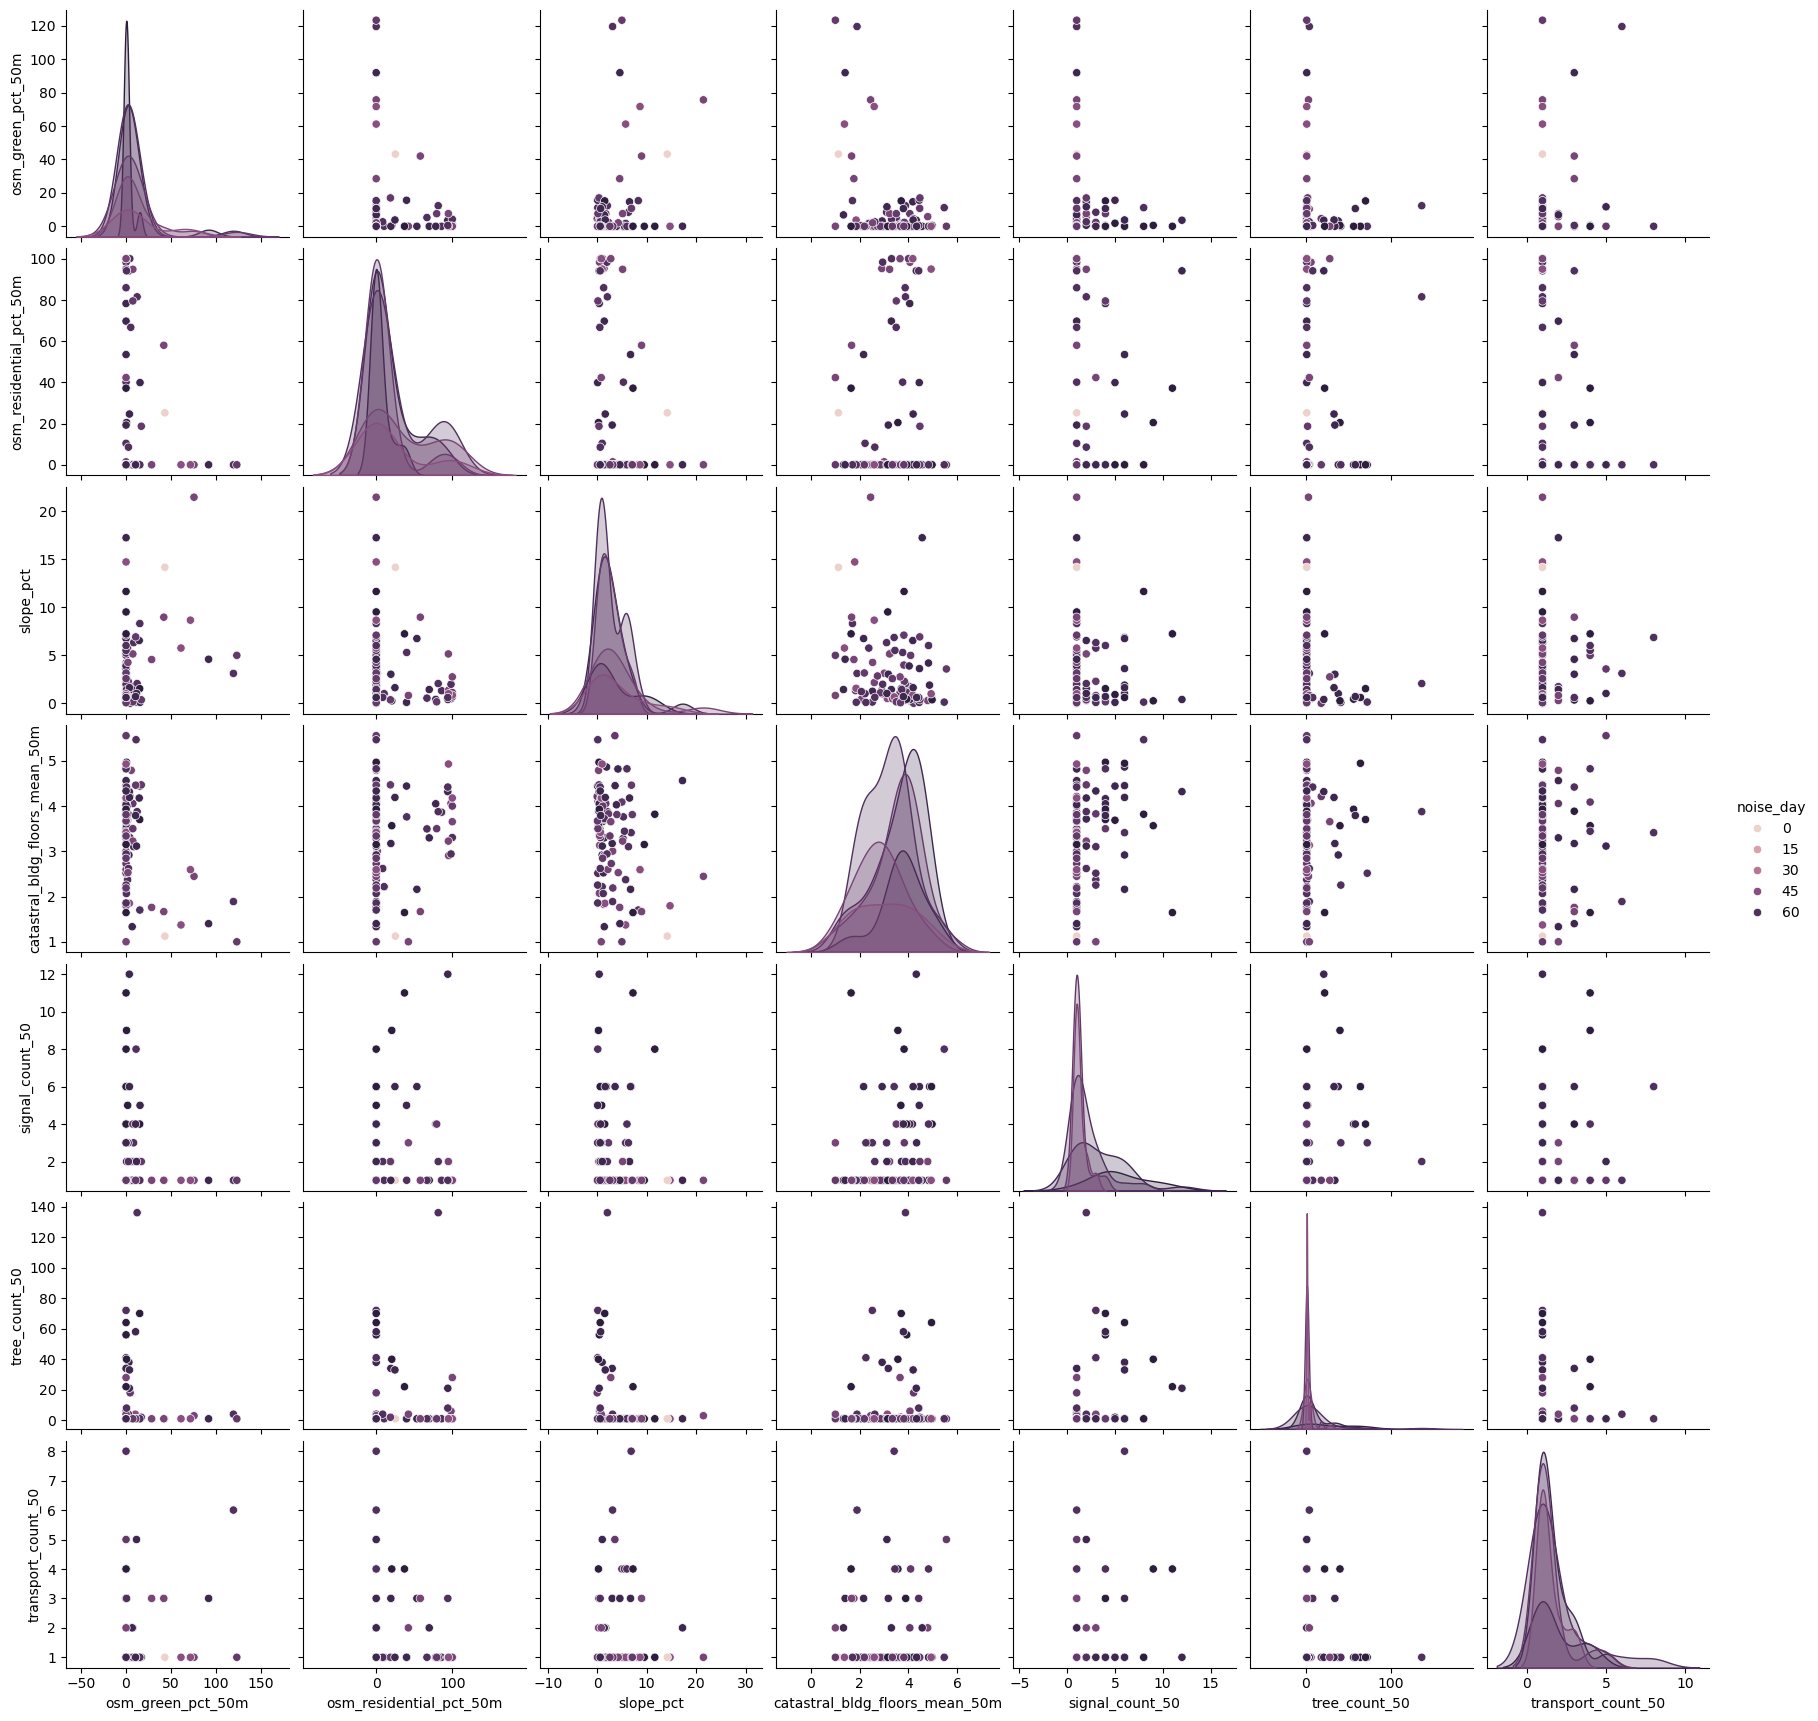

In [96]:
dataset_extra_small = dataset[['noise_day','road_category','osm_green_pct_50m','osm_residential_pct_50m', 'slope_pct', 'catastral_bldg_floors_mean_50m', 'signal_count_50','tree_count_50', 'transport_count_50']]
sns.pairplot(dataset_extra_small.head(100), hue="noise_day")

<Axes: >

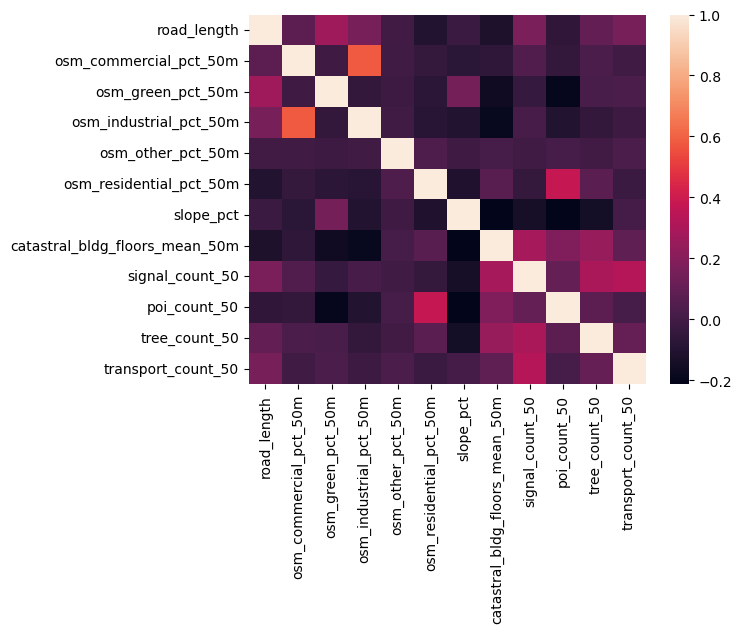

In [92]:
dataset_num = dataset_small.drop(columns=['road_category', 'noise_day', 'noise_evening', 'noise_night']) #dropping y and non-numeric columns
sns.heatmap(dataset_num.corr())

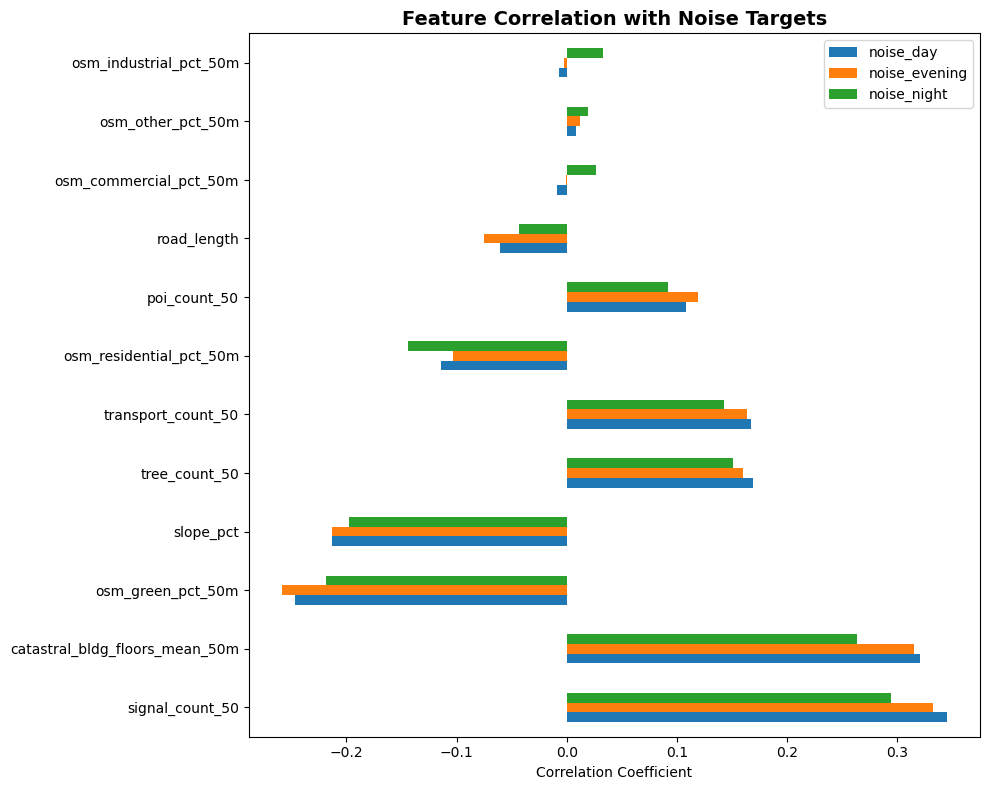

                                noise_day  noise_evening  noise_night
signal_count_50                  0.344719       0.332062     0.294125
catastral_bldg_floors_mean_50m   0.320282       0.314596     0.263665
tree_count_50                    0.168861       0.159956     0.151115
transport_count_50               0.167308       0.163824     0.143034
poi_count_50                     0.108261       0.119155     0.091414
osm_other_pct_50m                0.008713       0.011901     0.018894
osm_industrial_pct_50m          -0.006958      -0.002339     0.032499
osm_commercial_pct_50m          -0.008996      -0.001172     0.026702
road_length                     -0.060596      -0.075352    -0.043425
osm_residential_pct_50m         -0.113961      -0.102993    -0.144414
slope_pct                       -0.213041      -0.213049    -0.197983
osm_green_pct_50m               -0.246414      -0.258352    -0.218898


In [87]:
# Extract correlations with noise predictions
dataset_num = dataset_small.drop(columns=['road_category']) #dropping y and non-numeric columns
target_cols = ['noise_day', 'noise_evening', 'noise_night']
feature_correlation = dataset_num.corr()[target_cols].drop(target_cols)

# Sort by absolute correlation
feature_correlation_sorted = feature_correlation.abs().sort_values('noise_day', ascending=False)

# Plot bar chart
fig, ax = plt.subplots(figsize=(10, 8))
feature_correlation.loc[feature_correlation_sorted.index].plot(kind='barh', ax=ax)
ax.set_title('Feature Correlation with Noise Targets', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print(feature_correlation.sort_values('noise_day', ascending=False))

## Parallel Coordinates

In [88]:
# Select numeric columns
dataset_num = dataset_small.drop(columns=['road_category', 'noise_day', 'noise_evening', 'noise_night']) #dropping y and non-numeric columns
numeric_cols = dataset_num.columns.tolist()
print(f"Numeric columns: {numeric_cols}")


Numeric columns: ['road_length', 'osm_commercial_pct_50m', 'osm_green_pct_50m', 'osm_industrial_pct_50m', 'osm_other_pct_50m', 'osm_residential_pct_50m', 'slope_pct', 'catastral_bldg_floors_mean_50m', 'signal_count_50', 'poi_count_50', 'tree_count_50', 'transport_count_50']


### Day Noise

In [89]:
# Create parallel coordinates plot for day noise
fig_day = px.parallel_coordinates(
    dataset,
    dimensions=[col for col in numeric_cols],
    color='noise_day' if 'noise_day' in numeric_cols else numeric_cols[-1],
    color_continuous_scale='Viridis',
    labels={col: col.replace('_', ' ').title() for col in numeric_cols},
    title='Parallel Coordinates Plot - Actual Feature Values Colored by Day Noise',
    height=700,
    width=1400
)

fig_day.update_layout(
    font=dict(size=10),
    coloraxis_colorbar=dict(title="Day Noise Level")
)

fig_day.show()

### Evening Noise

In [90]:
# Create parallel coordinates plot for evening noise
fig_evening = px.parallel_coordinates(
    dataset,
    dimensions=[col for col in numeric_cols],
    color='noise_evening' if 'noise_evening' in numeric_cols else numeric_cols[-1],
    color_continuous_scale='RdYlGn_r',
    labels={col: col.replace('_', ' ').title() for col in numeric_cols},
    title='Parallel Coordinates Plot - Actual Feature Values Colored by Evening Noise',
    height=700,
    width=1400
)

fig_evening.update_layout(
    font=dict(size=10),
    coloraxis_colorbar=dict(title="Evening Noise Level")
)

fig_evening.show()

### Night Noise

In [91]:
# Create parallel coordinates plot for night noise
fig_night = px.parallel_coordinates(
    dataset,
    dimensions=[col for col in numeric_cols],
    color='noise_night' if 'noise_night' in numeric_cols else numeric_cols[-1],
    color_continuous_scale='Blues',
    labels={col: col.replace('_', ' ').title() for col in numeric_cols},
    title='Parallel Coordinates Plot - Actual Feature Values Colored by Night Noise',
    height=700,
    width=1400
)

fig_night.update_layout(
    font=dict(size=10),
    coloraxis_colorbar=dict(title="Night Noise Level")
)

fig_night.show()